<div dir="rtl" style="text-align: right; line-height: 1.9; font-family: 'Segoe UI', Tahoma, Arial, sans-serif; font-size: 16px;">

# 🎓 مسترکلاس مهندسی مالی تصادفی با پایتون
## فصل ۲: معماری داده‌های بازار و محاسبات بازده (Market Data Architecture & Returns Computation)

---
### 🎯 هدف این نوت‌بوک
در این آموزش تعاملی، ما مفاهیم بنیادین مهندسی مالی را با اصول **مهندسی نرم‌افزار شی‌گرا (OOP)** ترکیب می‌کنیم. یک تحلیلگر کمی (Quant) پیش از ساخت هرگونه مدل پیچیده تصادفی (مثل بلک-شولز یا شبیه‌سازی مونت‌کارلو)، نیازمند دو چیز است:
1. **زیرساخت داده‌ای مقاوم (Robust Data Pipeline):** سیستمی که به منبع داده (Yahoo یا MarketStack) وابسته نباشد.
2. **فهم ریاضیاتی بازده (Mathematical Returns):** تبدیل قیمت‌های ناایستا (Non-Stationary) به بازده‌های ایستا (Stationary).

### 📚 بخش ۱: آماده‌سازی محیط (Environment Setup)
ابتدا کتابخانه‌های مورد نیاز برای دریافت داده‌ها (مانند `yahoofinancials`) و ابزارهای تحلیلی (`pandas`, `matplotlib`) را نصب و بارگذاری می‌کنیم.

</div>

In [ ]:
# Install necessary packages for fetching data and visualization
!pip install yahoofinancials pandas matplotlib seaborn requests

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import sys
import enum
from abc import ABC, abstractmethod, ABCMeta
from typing import List, Dict, Any
from yahoofinancials import YahooFinancials

print("\n--- Setup Complete! Libraries are successfully loaded. ---")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for yahoofinancials: filename=yahoofinancials-1.20-py3-none-any.whl size=38618 sha256=b39ee134a78adf0386db1cfbce9de44a82974cf17b4e9ed30f7bdf015e21e8b0
  Stored in directory: /root/.cache/pip/wheels/b0/e1/ca/e683b02e57db550881c8ebb89ba3eccb7a5c0ebfad7f03acea
Successfully built yahoofinancials

--- Setup Complete! Libraries are successfully loaded. ---


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۲: تئوری معماری نرم‌افزار در مالی (الگوی Adapter)

در سیستم‌های معاملات الگوریتمی (Algo-Trading)، منابع داده پیوسته تغییر می‌کنند. اگر ما کدهای محاسبه بازده خود را مستقیماً به API یاهو متصل کنیم، با از کار افتادن یاهو، کل سیستم ما مختل می‌شود.

برای حل این مشکل از **الگوی طراحی آداپتور (Adapter Design Pattern)** استفاده می‌کنیم. ما یک قرارداد (کلاس انتزاعی `StockPriceDatasetAdapter`) می‌نویسیم. این قرارداد به سیستم می‌گوید: *"من اهمیتی نمی‌دهم داده‌ها را از کجا می‌آوری، فقط آن‌ها را در قالب یک دیتافریم شامل دو ستون `time` و `stock price` به من تحویل بده."*

</div>

In [ ]:
# --- Core Interfaces (Abstract Classes) ---

class Frequency(enum.Enum):
    DAILY = "daily"
    WEEKLY = "weekly"
    MONTHLY = "monthly"

class StockPriceDatasetAdapter(metaclass=ABCMeta):
    """
    Interface to access any data source of stock price quotes.
    Multiple implementations can be made to support different data sources.
    """
    DEFAULT_TICKER = "PFE" # Default to Pfizer

    @property
    @abstractmethod
    def training_set(self):
        """
        Returns a dataframe with two columns: stock price & time
        """
        ...

    @property
    @abstractmethod
    def validation_set(self):
        """
        Returns a dataframe with two columns: stock price & time
        """
        ...

class BaseStockPriceDatasetAdapter(StockPriceDatasetAdapter, ABC):
    def __init__(self, ticker: str = None):
        self._ticker = ticker
        self._training_set = None
        self._validation_set = None

    @abstractmethod
    def _connect_and_prepare(self, date_range: tuple):
        """
        This function should be overridden by the implementing data source adapter.
        """
        ...

    @property
    def training_set(self):
        return self._training_set.copy()

    @property
    def validation_set(self, ticker=None):
        return self._validation_set.copy()

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۳: پیاده‌سازی آداپتورهای واقعی (Yahoo & MarketStack)

اکنون کلاس‌های واقعی را می‌سازیم که از قرارداد بالا پیروی می‌کنند.
کلاس `YahooFinancialsAdapter` مستقیماً به API یاهو متصل شده و قیمت‌ها را استخراج می‌کند. کلاس `MarketStackAdapter` نشان می‌دهد که چگونه می‌توانیم از یک API دیگر با سیستم صفحه‌بندی (Pagination) استفاده کنیم، در حالی که خروجی نهایی برای مدل ریاضی ما کاملاً یکسان (Standardized) است.

</div>

In [ ]:
# --- Concrete Adapters ---

class YahooFinancialsAdapter(BaseStockPriceDatasetAdapter):
    """
    Dataset adapter for Yahoo Financials (https://finance.yahoo.com/).
    """
    def __init__(
        self,
        ticker=StockPriceDatasetAdapter.DEFAULT_TICKER,
        frequency=Frequency.DAILY,
        training_set_date_range=("2020-01-01", "2021-12-31"),
        validation_set_date_range=("2013-07-01", "2013-08-31"),
    ):
        super().__init__(ticker=ticker)
        self._frequency = frequency
        self._yf = YahooFinancials(self._ticker)
        # Connect and fetch data during initialization
        self._training_set = self._connect_and_prepare(training_set_date_range)
        self._validation_set = self._connect_and_prepare(validation_set_date_range)

    def _connect_and_prepare(self, date_range: tuple):
        records = self._yf.get_historical_price_data(
            date_range[0], date_range[1], self._frequency.value
        )[self._ticker]

        # Extract specific columns from the JSON response
        stock_price_records = pd.DataFrame(data=records["prices"])[["formatted_date", "close"]]

        # Rename columns to match the Interface Contract (time, stock price)
        stock_price_records.rename(
            columns={"formatted_date": "time", "close": "stock price"}, inplace=True
        )
        return stock_price_records


class MarketStackAdapter(BaseStockPriceDatasetAdapter):
    """
    Dataset adapter for Market Stack API with Pagination support.
    """
    _REQ_PARAMS = {"access_key": "ce72d47022d573ffb1c47820c7e98f15", "limit": 500}
    _EOD_API_URL = "http://api.marketstack.com/v1/eod"
    _TICKER_API_URL = "http://api.marketstack.com/v1/tickers"

    class _PaginatedRecords:
        def __init__(self, api_url, req_params):
            self._req_params = req_params
            self._offset = 0
            self._total_records = sys.maxsize
            self._api_url = api_url

        def __getitem__(self, index):
            if (self._offset + self._req_params["limit"]) >= self._total_records:
                raise StopIteration()
            self._req_params["offset"] = self._offset
            api_response = requests.get(self._api_url, self._req_params).json()
            self._total_records = api_response["pagination"]["total"]
            self._offset = self._offset + self._req_params["limit"] + 1
            return api_response["data"]

    def __init__(
        self,
        training_set_date_range=("2020-01-01", "2021-12-31"),
        validation_set_date_range=("2013-07-01", "2013-08-31"),
        ticker: str = None,
    ):
        super().__init__(ticker=ticker)
        self._training_set = self._connect_and_prepare(training_set_date_range)

    def _connect_and_prepare(self, date_range: tuple):
        def _extract_stock_price_details(stock_price_records, page):
            ticker_symbol = page["symbol"]
            stock_record_per_symbol = stock_price_records.get(ticker_symbol)
            if stock_record_per_symbol is None:
                stock_record_per_symbol = pd.DataFrame()

            entry = {"stock price": [page["close"]], "time": [page["date"].split("T")[0]]}
            stock_price_records[ticker_symbol] = pd.concat(
                [stock_record_per_symbol, pd.DataFrame(entry)], ignore_index=True
            )
            return stock_price_records

        if self._ticker is None:
            return None

        req_params = MarketStackAdapter._REQ_PARAMS.copy()
        req_params["symbols"] = self._ticker
        req_params["date_from"] = date_range[0]
        req_params["date_to"] = date_range[1]
        stock_price_records = {}

        for records in MarketStackAdapter._PaginatedRecords(api_url=MarketStackAdapter._EOD_API_URL, req_params=req_params):
            for page in records:
                stock_price_records = _extract_stock_price_details(stock_price_records, page)

        return stock_price_records

    @classmethod
    def get_samples_of_available_tickers(cls):
        api_response = requests.get(MarketStackAdapter._TICKER_API_URL, MarketStackAdapter._REQ_PARAMS).json()
        return [record["symbol"] for record in api_response["data"]]

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۴: مصورسازی داده‌ها (Data Visualization Module)

در مهندسی مالی، تکیه بر اعداد خام کافی نیست. ما از ماژول زیر (کدهای `visualization.py`) برای رسم مسیر قیمت سهام و نوسانات بازده استفاده می‌کنیم. دقت کنید که کدهای این بخش با استفاده از `match-case` (معرفی شده در پایتون ۳.۱۰) به صورت داینامیک تعداد نمودارها را بر اساس تعداد نمادهای ورودی تنظیم می‌کنند.

</div>

In [ ]:
# --- Visualization Engine ---

def plot_security_prices(all_records: Dict[str, Any], security_type):
    """
    Dynamically plots security prices in a grid layout.
    """
    plt.style.use("seaborn-v0_8")
    n = len(all_records)
    rows = int(n/2) if n > 1 else 1
    cols = 2 if n > 1 else 1

    fig, ax = plt.subplots(rows, cols, figsize=(10, 4 * rows))
    i = 0
    r = 0
    security_names = list(all_records.keys())

    def _axis_plot_security_prices(records, col, name):
        match n:
               case 1:
                        ax.set_title(name)
                        records.plot(ax=ax, x="time", y=security_type, color='darkblue')
               case 2:
                        ax[col].set_title(name)
                        records.plot(ax=ax[col], x="time", y=security_type, color='darkblue')
               case _:
                        ax[r, col].set_title(name)
                        records.plot(ax=ax[r, col], x="time", y=security_type, color='darkblue')

    while i < n:
        _axis_plot_security_prices(all_records[security_names[i]], 0, security_names[i])
        i = i + 1
        if n > 1 and i < n:
           _axis_plot_security_prices(all_records[security_names[i]], 1, security_names[i])
        i = i + 1
        r = r + 1

    fig.tight_layout()
    plt.show()

def plot_returns_for_different_periods(ticker, periodic_returns: List[tuple]):
    """
    Plots returns for Daily, Weekly, and Monthly frequencies.
    """
    plt.style.use("seaborn-v0_8")
    fig, ax = plt.subplots(len(periodic_returns), 1, figsize=(10, 8))

    for index, t in enumerate(periodic_returns):
        t[1].plot(ax=ax[index], x="time", y="Return", color='teal')
        ax[index].axhline(0, color='black', linestyle='--', linewidth=0.8)
        ax[index].set_title(ticker + " - " + t[0] + " Returns")

    fig.tight_layout()
    plt.show()

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۵: تست پایگاه داده و درک ناایستایی (Non-Stationarity)

در اینجا ما کد `test_dataset_adapters.py` را اجرا می‌کنیم تا داده‌های اپل (AAPL) و گوگل (GOOG) را دریافت و رسم کنیم.
**تحلیل ریاضی:** با نگاه به نمودار خروجی، متوجه می‌شویم که قیمت‌ها دارای یک روند رو به رشد (Trend) هستند. در آمار، سری زمانی که میانگین و واریانس آن در طول زمان تغییر کند، **ناایستا (Non-Stationary)** نامیده می‌شود. مدلسازی تصادفی روی داده‌های ناایستا باعث تولید "رگرسیون کاذب" (Spurious Regression) می‌شود.

برای حل این بحران ریاضی، باید از «بازده» استفاده کنیم.

</div>

Fetching Data for Apple and Google...
Plotting Non-Stationary Prices:


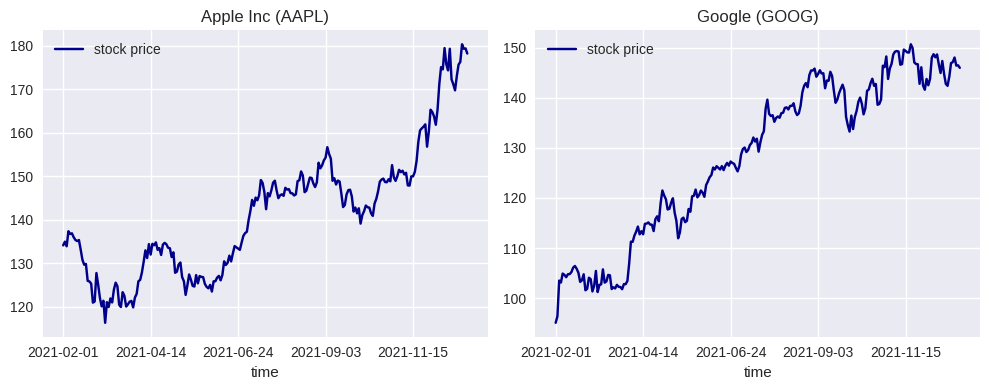

In [ ]:
# --- Testing Dataset Adapters & Observing Prices ---

def test_yahoo_financials_adapter():
    print("Fetching Data for Apple and Google...")
    records = {
        'Apple Inc (AAPL)': YahooFinancialsAdapter(
            ticker="AAPL",
            training_set_date_range=("2021-02-01", "2021-12-31"),
        ).training_set,

        'Google (GOOG)': YahooFinancialsAdapter(
            ticker="GOOG",
            training_set_date_range=("2021-02-01", "2021-12-31"),
        ).training_set
    }

    print("Plotting Non-Stationary Prices:")
    plot_security_prices(records, 'stock price')

test_yahoo_financials_adapter()

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۶: ریاضیات بازده دارایی (Returns Computation)

برای تبدیل سری زمانی قیمت ($S_t$) به یک سری زمانی ایستا، از **بازده ساده (Simple Return)** استفاده می‌کنیم. رابطه ریاضی آن به شرح زیر است:

$$ R_t = \frac{S_t - S_{t-1}}{S_{t-1}} = \frac{S_t}{S_{t-1}} - 1 $$

در کد `return_computation.py`، نویسنده برای پیاده‌سازی این فرمول در پانداس از تابع `.shift(1)` استفاده کرده است. این کار مقادیر ستون قیمت را یک ردیف به پایین می‌لغزاند که دقیقاً معادل کسر $\frac{S_t}{S_{t-1}}$ است. این روش به آن عملیات برداری (Vectorization) می‌گویند که بسیار سریع‌تر از حلقه‌های تو در تو است.

</div>

In [ ]:
# --- Return Computation Logic ---

def compute_returns():
    """
    Calculates simple returns for Daily, Weekly, and Monthly frequencies.
    Mathematical concept implemented: R_t = S_t / S_{t-1} - 1
    """
    print("Computing returns for Pfizer (PFE)...")

    # 1. Monthly Returns
    monthly = YahooFinancialsAdapter(frequency=Frequency.MONTHLY, training_set_date_range=("2020-01-01", "2022-01-01")).training_set
    monthly["Return"] = monthly["stock price"] / monthly["stock price"].shift(1) - 1
    monthly.dropna(inplace=True) # Drop first NaN row

    # 2. Weekly Returns
    weekly = YahooFinancialsAdapter(frequency=Frequency.WEEKLY, training_set_date_range=("2020-01-01", "2022-01-01")).training_set
    weekly["Return"] = weekly["stock price"] / weekly["stock price"].shift(1) - 1
    weekly.dropna(inplace=True)

    # 3. Daily Returns
    daily = YahooFinancialsAdapter(frequency=Frequency.DAILY, training_set_date_range=("2020-01-01", "2022-01-01")).training_set
    daily["Return"] = daily["stock price"] / daily["stock price"].shift(1) - 1
    daily.dropna(inplace=True)

    # Package them for visualization
    periodic_returns = [("Daily", daily), ("Weekly", weekly), ("Monthly", monthly)]

    return periodic_returns

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۷: اجرای نهایی و تحلیل پدیده‌های تصادفی
در گام آخر (شبیه‌ساز فایل `run-chapter2.py`)، تمامی محاسبات بازده را فراخوانی کرده و رسم می‌کنیم.
**خروجی مورد انتظار:** با دقت به نمودار بازده روزانه (Daily Returns) نگاه کنید. دوره‌هایی وجود دارند که نوسانات بسیار بزرگ هستند و دوره‌هایی که نوسانات کوچک‌اند. به این پدیده **خوشه‌بندی نوسانات (Volatility Clustering)** می‌گویند. این پدیده باعث می‌شود توزیع بازده‌های مالی دارای «دم‌های پهن» (Fat Tails) باشد؛ مفهومی که در فصل بعدی (توزیع‌های احتمال) عمیقاً بررسی خواهد شد.

</div>

Computing returns for Pfizer (PFE)...
Plotting Periodic Returns (Notice the Volatility Clustering in Daily returns):


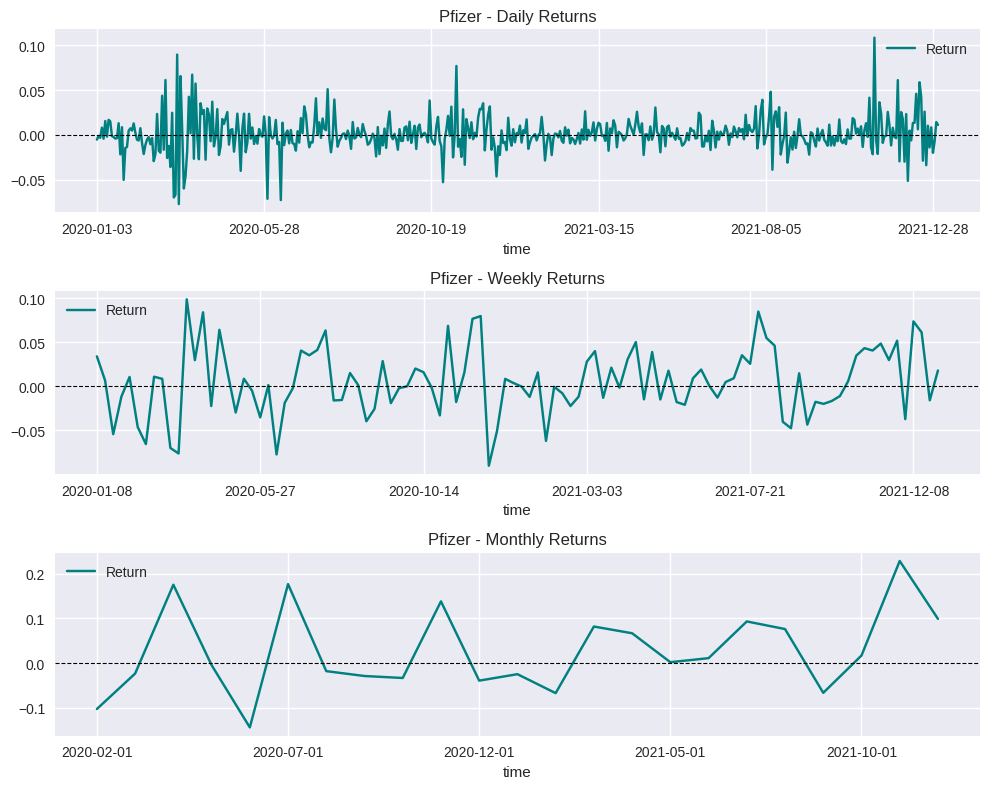


--- Chapter 2 Successfully Completed! ---


In [ ]:
# --- Final Execution (Analogous to run-chapter2.py) ---

def test_plot_periodic_returns():
    """
    Executes the return computation and displays the volatility clustering phenomenon.
    """
    periodic_returns = compute_returns()
    print("Plotting Periodic Returns (Notice the Volatility Clustering in Daily returns):")
    plot_returns_for_different_periods("Pfizer", periodic_returns)

if __name__ == "__main__":
    # Run the main execution pipeline for Chapter 2
    test_plot_periodic_returns()
    print("\n--- Chapter 2 Successfully Completed! ---")